# Plot the global time series for a given model and variable

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Set parameters

In [2]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['fgco2']#['fgco2','intpp','tas','tos','npp','nbp','cLand','cSoil','cVeg'] # 'tas','tos',['dissic']#
models = ['GFDL-ESM2M','IPSL-CM6-ESMCO2','NorESM2-LM','GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1','MIROC-ES2L','CESM2','ACCESS-ESM1-5']#[]#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

## Convert time series

In [6]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'fgco2' and stat == 'integral' and da.units in ['mmol/m^3 cm/s x m2']:
        converter = 10**-5 * 12.0107/ 1000 / 1000 / 1000 / 1000 / 1000 * 24 * 3600 * 365
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'dissic' and stat == 'integral' and vert_stat == 'integral' and da.units in ['mol m-3 x m x m2']:
        converter = 12.0107 /1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da
    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['dissic','fgco2','intpp','nbp','npp','cLand','cSoil','cVeg']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat

def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix    

## Load and plot individual models, yearly means (and monthly means if available)

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

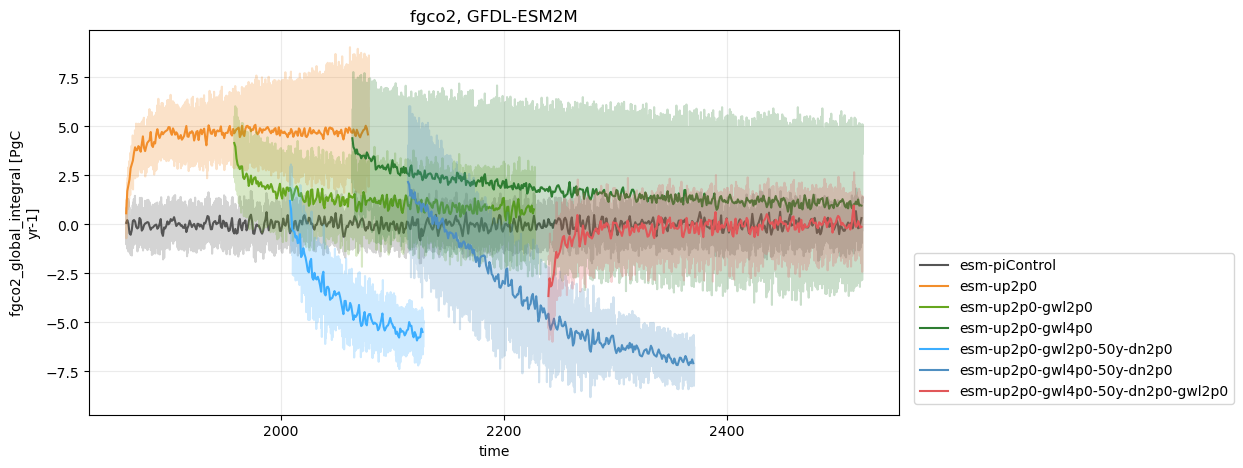

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

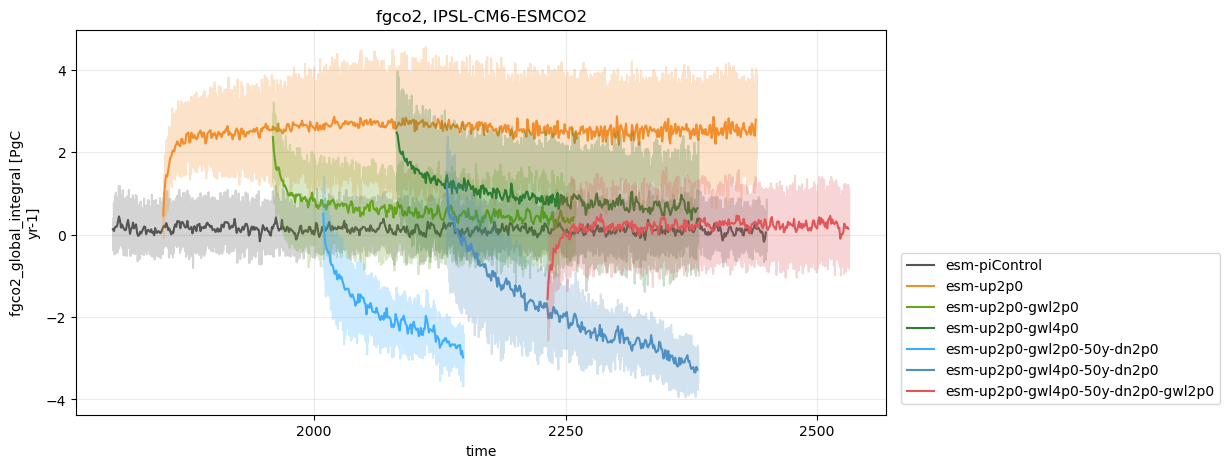

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

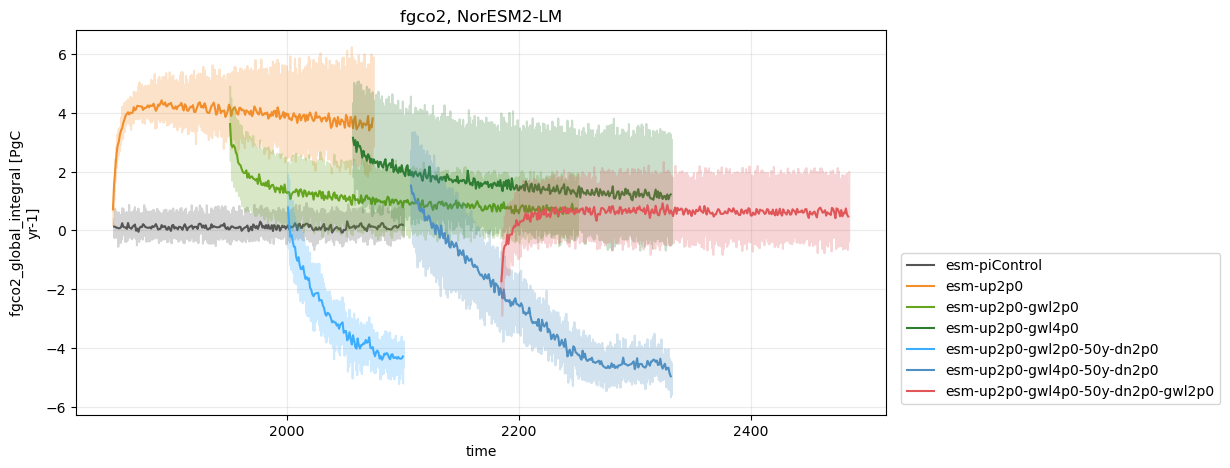

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

Nothing to plot for fgco2, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly, global integral.


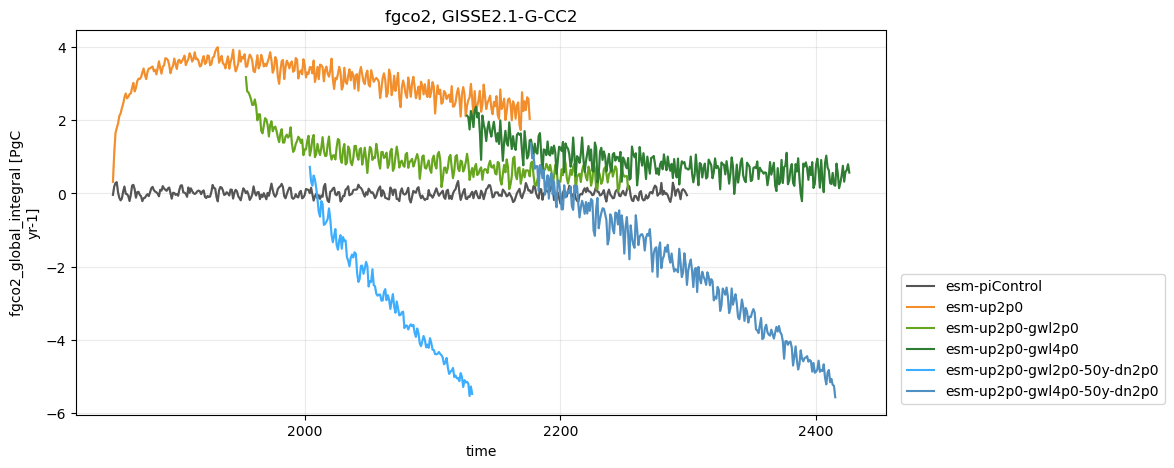

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

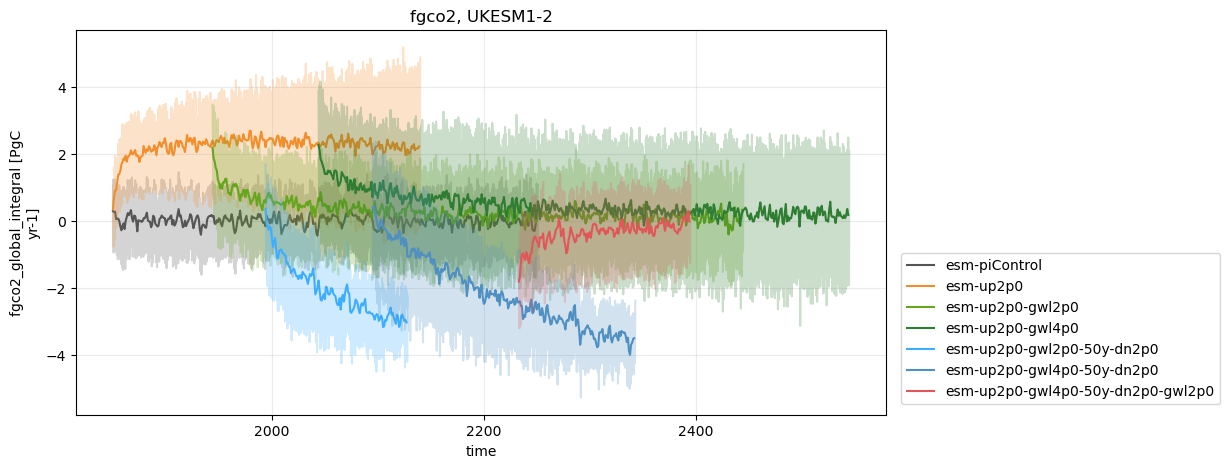

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

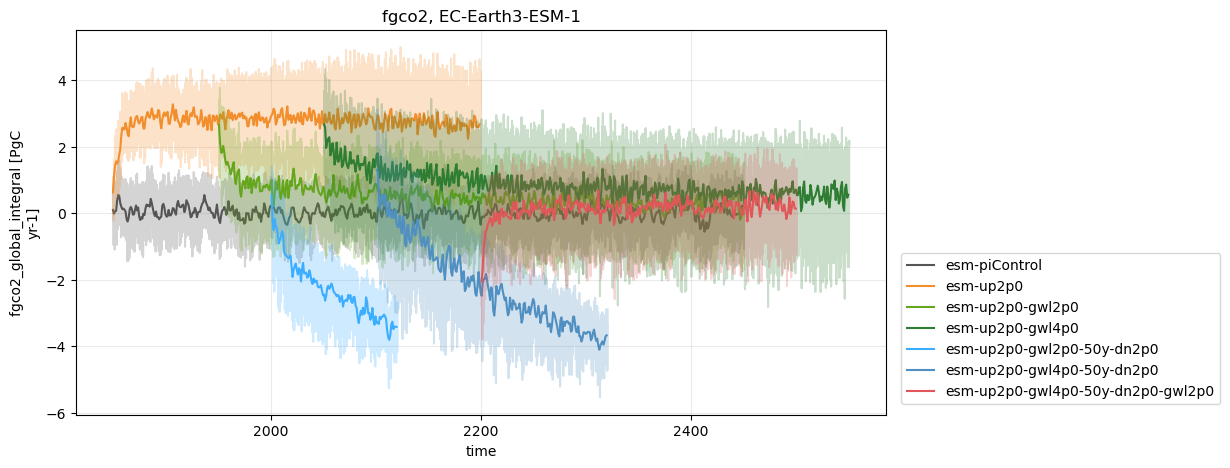

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

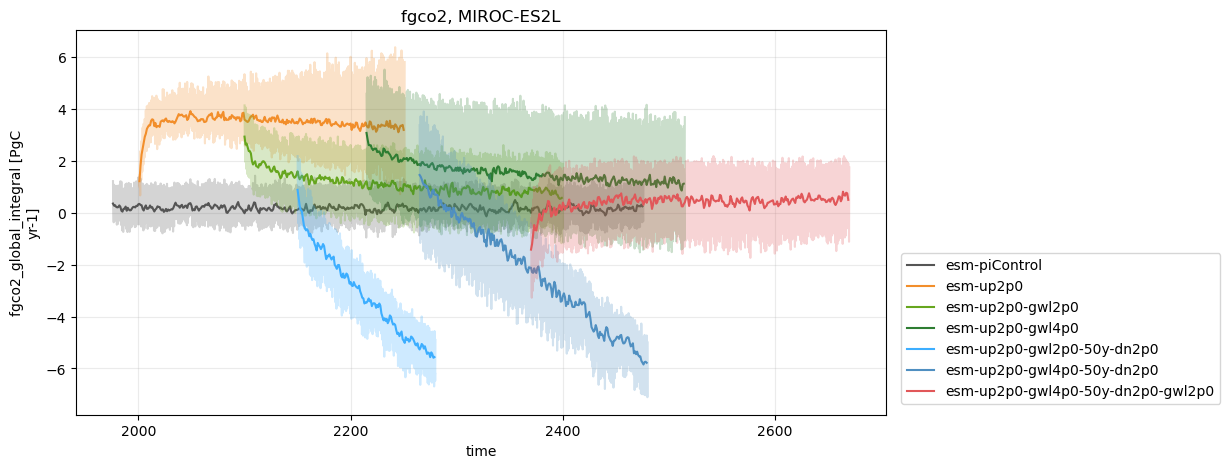

/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

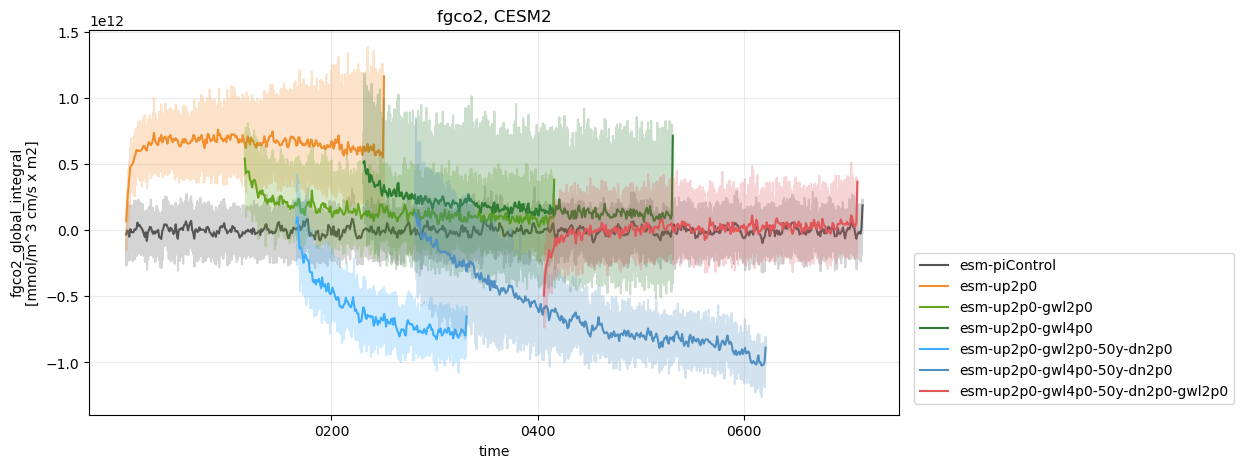

Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-piControl, monthly, global integral.


/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1437611188.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

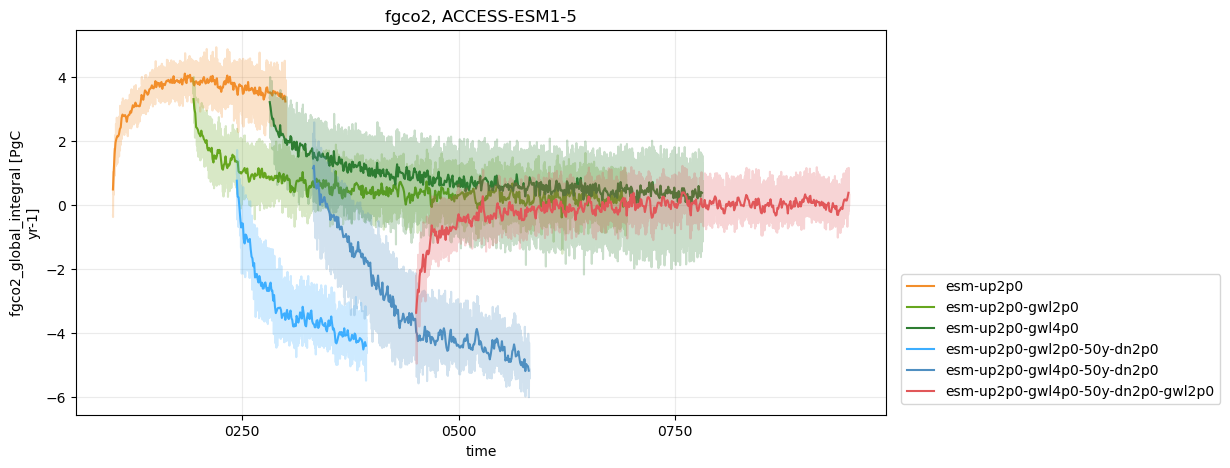

In [4]:
for varia in varias:
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        vert_stat = get_vert_stat(varia,default=True)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        infix = get_infix(varia,default=True)
        #color = model_dict[model].color_id
        global_stats = dict()
        fig, ax = plt.subplots(figsize=(12,5))
        for run in runs:
            try:
                color = run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}"]
                
                # convert
                global_stat = convert_units(varia,stat,global_stat)
    
                # put into dictionary
                global_stats[run] = global_stat
                #for key in global_stats.keys():
                #print(f'... plotting {run} ...')
                global_stats[run].plot(alpha=0.25,color=color)
                global_stats[run].resample(time="1YS").mean().plot(alpha=1,color=color,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        ax.set_title(f'{varia}, {model}')
        ax.grid(alpha=0.25)
        plt.subplots_adjust(right=0.8)
        plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
        plt.show()

## Plot all models together for a given variable (annual means only and a n-year running mean, n=11)

/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

Nothing to plot for fgco2, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly, global integral.


/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-piControl, monthly, global integral.


/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/1969199610.py:17: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg in

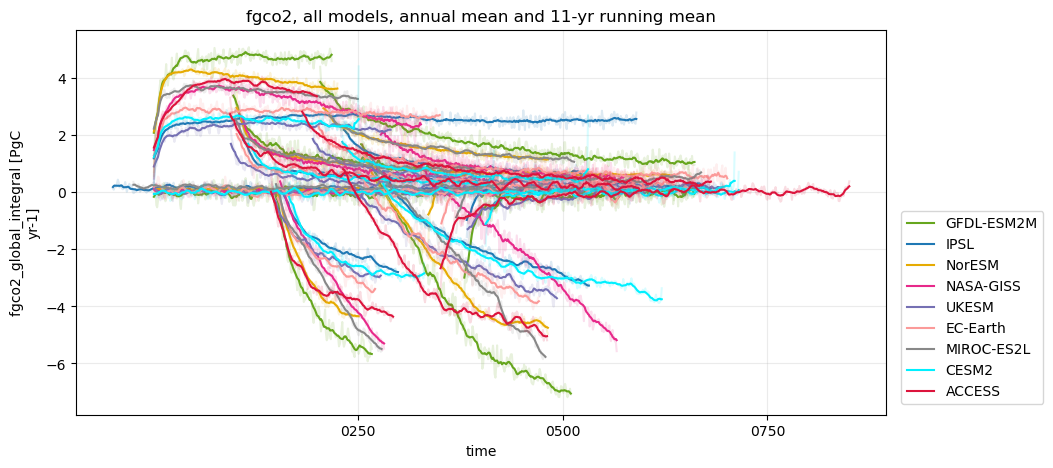

In [7]:
running_mean_years = 11

for varia in varias:
    fig, ax = plt.subplots(figsize=(12,5))
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        #color = model_dict[model].color_id
        global_stats = dict()
        for run in runs:
            try:
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}"]
    
                # now make sure all time series are centered to start with the rampup at 1850
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
                
                # convert
                global_stat = convert_units(varia,stat,global_stat)
    
                # put into dictionary
                global_stats[run] = global_stat
    
                annual_means = global_stat.resample(time="1YS").mean()
                annual_means.plot(alpha=.15,color=color)#,label=run)
    
                if run == 'esm-up2p0':
                    label=model_dict[model].plotting_name#model
                else:
                    label=''
                annual_means.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
                
    ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
    ax.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()

## Now plot the change (instead of the absolute value) for all models together for a given variable (annual means only and a n-year running mean, n=11)
Use the 1850 value of the pre-industrial simulation as reference value

/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:38: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg inst

Nothing to plot for fgco2, NorESM2-LM, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for fgco2, NorESM2-LM, r1i1p1f1, esm-up2p0, monthly, global integral.


/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


Nothing to plot for fgco2, NorESM2-LM, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for fgco2, NorESM2-LM, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.


/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)


...

Nothing to plot for fgco2, NorESM2-LM, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:38: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg inst

Nothing to plot for fgco2, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly, global integral.


/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:38: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  global_stat = xr.open_dataset(load_string,use_cftime=True)
/tmp/ipykernel_235620/2783318483.py:9: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg inst

Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-piControl, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl2p0-50y-dn2p0, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0, monthly, global integral.
Nothing to plot for fgco2, ACCESS-ESM1-5, r1i1p1f1, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, monthly, global integral.


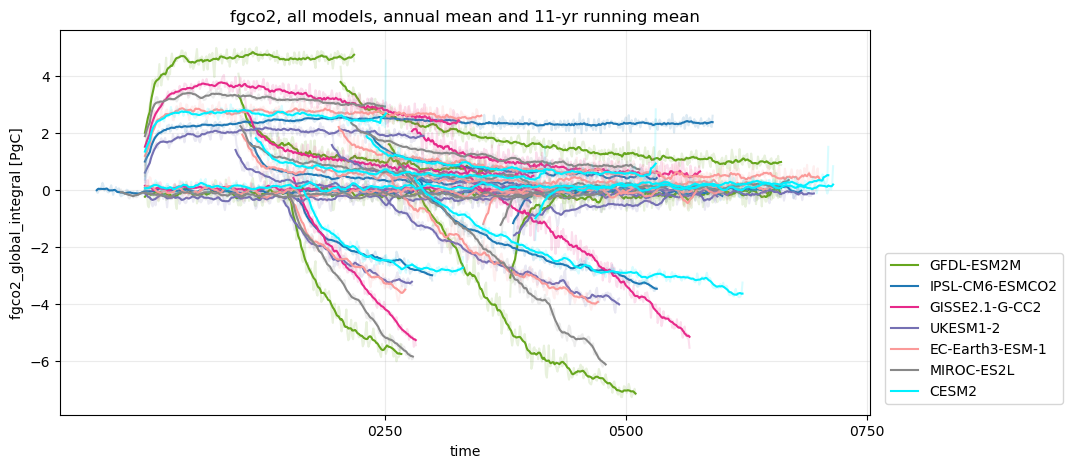

In [8]:
def get_reference_value(varia,model):
    freq_input = get_freq_input(model)
    stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    run = 'esm-piControl'
    load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
    load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
    global_stat = xr.open_dataset(load_string,use_cftime=True)
    global_stat = global_stat[f"{varia}_{infix}global_{stat}"]

    #ref_year = 1
    global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)
    annual_means = global_stat.resample(time="1YS").mean()
    reference_value = annual_means.sel(time=f'{ref_year:04d}-01-01').values
    
    return reference_value

running_mean_years = 11

for varia in varias:
    fig, ax = plt.subplots(figsize=(12,5))
    for model in models:
        freq_input = get_freq_input(model)
        stat = get_stat(varia)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        #print(varia,model)
        #print(varia,model,reference_value)
        #color = model_dict[model].color_id
        global_stats = dict()
        for run in runs:
            try:
                reference_value = get_reference_value(varia,model)
                color = model_dict[model].color_id#run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_{infix}global_{stat}"]
                global_stat = TimeOperator.shift_time_axis_to_ref_year(model,global_stat,ref_year=ref_year,set_to_start_of_months=True)

                annual_means = global_stat.resample(time="1YS").mean() - reference_value
                annual_means.attrs['units'] = global_stat.units
    
                # convert
                annual_means = convert_units(varia,stat,annual_means)
    
                # put into dictionary
                global_stats[run] = annual_means
    
                if run == 'esm-up2p0':
                    label=model
                else:
                    label=''
                annual_means.plot(alpha=.15,color=color)#,label=run)
                annual_means.rolling(time=running_mean_years,center=True,min_periods=1).mean().plot(alpha=1,color=color,label=label)#,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
                
    ax.set_title(f'{varia}, all models, annual mean and {running_mean_years}-yr running mean')
    ax.grid(alpha=0.25)
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
    plt.show()